# WNN on in vitro data only

In [3]:
here::i_am("rna_atac/dimensionality_reduction/WNN_MOFA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(batchelor))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 1)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [4]:
args = list()
# ATAC
args$atac_metadata = file.path(io$basedir, 'results/atac/archR/qc/sample_metadata_update_PeakClusters.txt.gz')
args$atac_lsi = file.path(io$basedir, 'results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_FALSE/batch_correction_None/lsi_nfeatures25000_dims35.txt.gz')
# RNA
args$rna_metadata = file.path(io$basedir, 'results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz')
args$rna_pca = file.path(io$basedir, 'results/rna/dimensionality_reduction/sce/regression/regressed_pca_feature4000_pcs30.txt.gz')
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

args$regression_out = file.path(io$basedir, 'results/rna/regression/')
dir.create(args$regression_out, recursive=TRUE, showWarnings =FALSE)
# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [5]:
##########################
## Load sample metadata ##
##########################

metadata_atac <- fread(args$atac_metadata) %>%
  .[pass_atacQC==TRUE & doublet_call==FALSE | pass_atacQC==TRUE & is.na(doublet_call)] %>% 
  .[,exp := str_replace_all(sample, opts$sample2exp)]

metadata_rna <- fread(args$rna_metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>% 
  .[,exp := str_replace_all(sample, opts$sample2exp)]

#### Plotting functions

In [6]:
plot_umap = function(umap.dt){

dot_size = 5
text_size = 15
title_size = 20

# Plot umap
p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
    geom_point(size=0.2) + 
    scale_color_manual(values=c('exp1' = 'deepskyblue', 'exp2' = 'salmon'), name='') +
    guides(colour = guide_legend(override.aes = list(size=dot_size))) + 
    ggtitle('Experiment') +
    theme_void() +
    theme(text=element_text(size=text_size), 
         plot.title=element_text(size=title_size), 
         legend.position='bottom')

umap.dt$day_genotype = paste0(umap.dt$day, '-', umap.dt$genotype)
umap.dt$day_genotype = gsub('wt', 'WT', umap.dt$day_genotype)
umap.dt$day_genotype = gsub('eomes_ko', 'KD', umap.dt$day_genotype)
umap.dt$day_genotype = factor(umap.dt$day_genotype, levels=c('D3-WT','D3.5-WT','D3.5-KD','D4-WT','D4-KD','D4.5-WT','D4.5-KD','D5-WT','D5-KD'))

# Plot umap
p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=day_genotype)) + 
    geom_point(size=0.2) + 
    scale_color_manual(values=c('D3-WT' = 'purple', 
                                'D3.5-WT' = 'darkgreen', 
                                'D3.5-KD' = 'limegreen',
                                'D4-WT' = 'darkgoldenrod', 
                                'D4-KD' = 'gold',
                                'D4.5-WT' = 'darkblue',
                                'D4.5-KD' = 'deepskyblue', 
                                'D5-WT' = 'darkred',
                                'D5-KD' = 'red'
                               ), name='') +
    guides(colour = guide_legend(override.aes = list(size=dot_size))) + 
    ggtitle('Day-Genotype') +
    theme_void() +
    theme(text=element_text(size=text_size), 
         plot.title=element_text(size=title_size), 
         legend.position='bottom')

# Plot umap
p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
    geom_point(size=0.2) + 
    scale_color_manual(values=c('wt' = 'black', 'eomes_ko' = 'red'), name='') + 
    guides(colour = guide_legend(override.aes = list(size=dot_size))) + 
    ggtitle('Genotype') +
    theme_void() +
    theme(text=element_text(size=text_size), 
         plot.title=element_text(size=title_size), 
         legend.position='bottom')

options(repr.plot.width=20, repr.plot.height=6)
plots = ggarrange(p1, p2, p3, ncol=3)
return(plots)
}

### Load files

In [7]:
# load LSI
LSI = fread(args$atac_lsi)

# load PCA
PCA = fread(args$rna_pca)

In [8]:
# Filter cells
cells_keep = intersect(metadata_atac$cell, metadata_rna$cell)
metadata_atac = metadata_atac[match(cells_keep, cell)]
metadata_rna = metadata_rna[match(cells_keep, cell)]

# metadata_atac contains all info from RNA as well as ATAC
sample_metadata = metadata_atac

# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = sample_metadata$cell)

In [9]:
sample_metadata = sample_metadata[,Clusters_PeakMatrix2:=NULL] # need to remove duplicated column

In [10]:
fwrite(sample_metadata, sprintf('%s/results/rna_atac/combined_metadata.txt.gz',io$basedir))

In [8]:
# format LSI
LSI = LSI[match(sample_metadata$cell, cell)] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix(.)

# format PCA
PCA = PCA[match(sample_metadata$cell, cell)] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix(.)

In [9]:
## Create Seurat object
seurat = as.Seurat(rna.sce)

# Add dimensionality reductions
seurat[["PCA"]] <- CreateDimReducObject(embeddings = PCA, key = "PC_", assay = DefaultAssay(seurat))
seurat[["LSI"]] <- CreateDimReducObject(embeddings = LSI, key = "LSI_", assay = DefaultAssay(seurat))

seurat[["PCA_scaled"]] <- CreateDimReducObject(embeddings = scale(PCA), key = "PC_", assay = DefaultAssay(seurat))
seurat[["LSI_scaled"]] <- CreateDimReducObject(embeddings = scale(LSI), key = "LSI_", assay = DefaultAssay(seurat))

Warning message:
“Cannot add objects with duplicate keys (offending key: PC_), setting key to 'pca_scaled_'”
Warning message:
“Cannot add objects with duplicate keys (offending key: LSI_), setting key to 'lsi_scaled_'”


In [10]:
seurat[["PCA_LSI"]] <- CreateDimReducObject(embeddings = cbind(scale(LSI)[,1:30], scale(PCA)[,1:30]), key = "concat_", assay = DefaultAssay(seurat))

### WNN raw DimRedu

In [71]:
seurat <- FindMultiModalNeighbors(seurat, 
                                  reduction.list = list("PCA", "LSI"), 
                                  dims.list = list(1:30, 1:30), 
                                  modality.weight.name = "RNA.weight", 
                                  verbose=FALSE
)

Warning message in FindMultiModalNeighbors(seurat, reduction.list = list("PCA", :
“The number of provided modality.weight.name is not equal to the number of modalities. RNA.weight RNA.weight are used to store the modality weights”


In [72]:
seurat <- RunUMAP(seurat, 
                  nn.name = "weighted.nn", 
                  reduction.name = "wnn.umap", 
                  reduction.key = "wnnUMAP_",
                  n.neighbors = 25L,
                  min.dist = 0.3,
                  metric = 'euclidean',
                  verbose = FALSE)

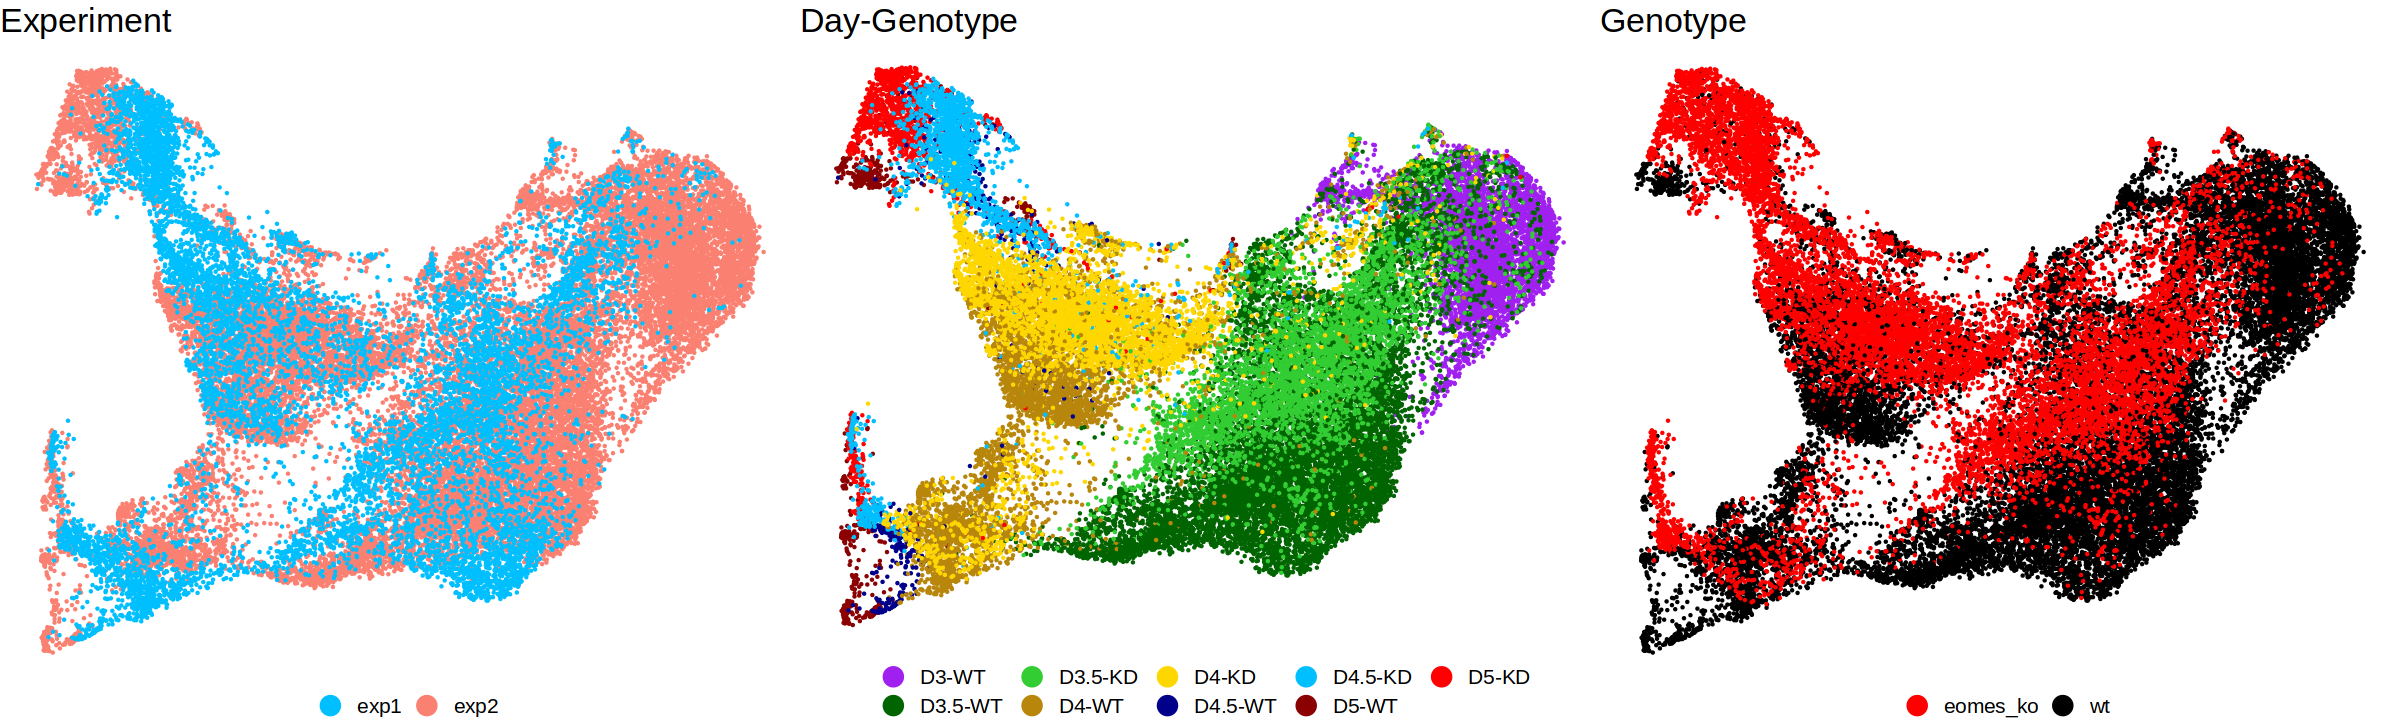

In [73]:
umap.dt = as.data.table(seurat@reductions$wnn.umap@cell.embeddings, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    merge(., sample_metadata, by='cell')
plot_umap(umap.dt)

### WNN scaled DimRedu

In [46]:
seurat <- FindMultiModalNeighbors(seurat, 
                                  reduction.list = list("PCA_scaled", "LSI_scaled"), 
                                  dims.list = list(1:30, 1:30), 
                                  modality.weight.name = "RNA.weight", 
                                  verbose=FALSE
)

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from normpca_scaled_ to normpcascaled_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to normpcascaled_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from normlsi_scaled_ to normlsiscaled_”
Warning message:
“All keys should be one or more alphanumeric characters followed by an underscore '_', setting key to normlsiscaled_”
Warning message in FindMultiModalNeighbors(seurat, reduction.list = list("PCA_scaled", :
“The number of provided modality.weight.name is not equal to the number of modalities. RNA.weight RNA.weight are used to store the modality weights”


In [47]:
seurat <- RunUMAP(seurat, 
                  nn.name = "weighted.nn", 
                  reduction.name = "wnn.umap", 
                  reduction.key = "wnnUMAP_",
                  n.neighbors = 25L,
                  min.dist = 0.3,
                  metric = 'euclidean',
                  verbose = FALSE)

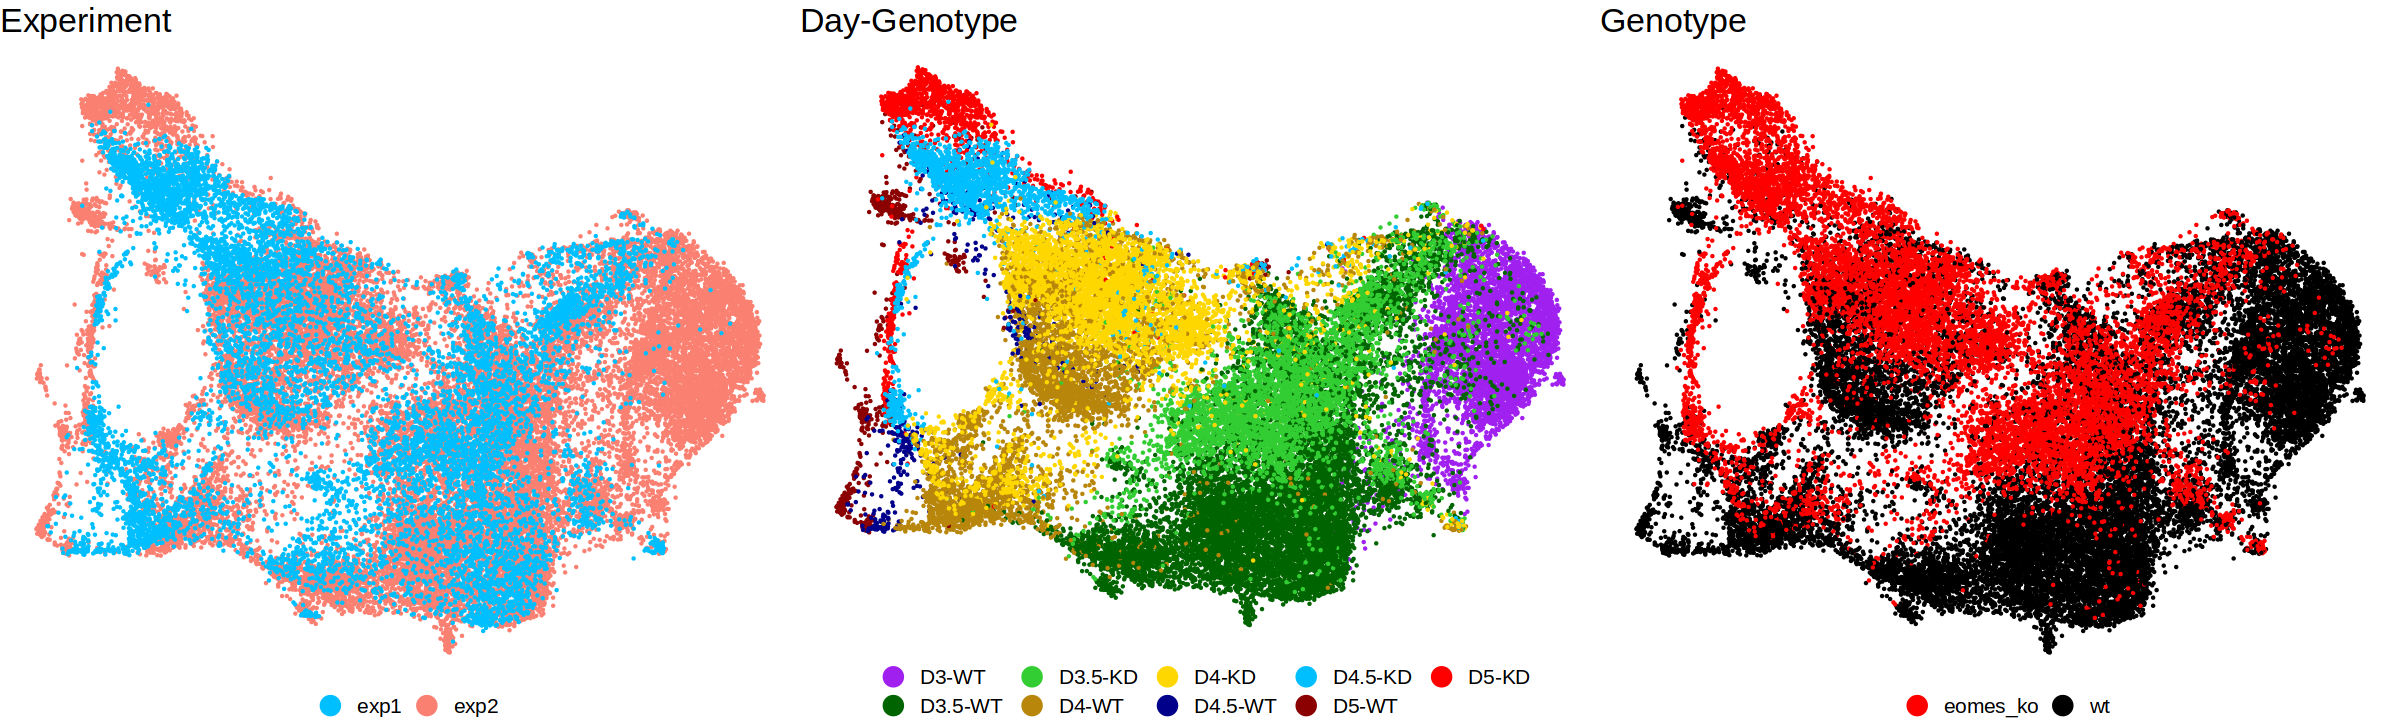

In [48]:
umap.dt = as.data.table(seurat@reductions$wnn.umap@cell.embeddings, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    merge(., sample_metadata, by='cell')
plot_umap(umap.dt)

In [54]:
pdf(sprintf('%s/wnn/WNN_umap.pdf', args$outdir), width=15, height=5)
    plot_umap(umap.dt[,UMAP1:=UMAP1*-1])
dev.off()

png 
  2

### UMAP on concatenated DimRedus

In [55]:
seurat[["PCA_LSI"]] <- CreateDimReducObject(embeddings = cbind(scale(LSI)[,1:30], scale(PCA)[,1:30]), key = "concat_", assay = DefaultAssay(seurat))

In [57]:
seurat <- RunUMAP(seurat, 
  reduction = "PCA_LSI",
  dims = 1:60,
  n.neighbors = 25,
  min.dist = 0.3,
  metric = 'euclidean',
  verbose=FALSE
)

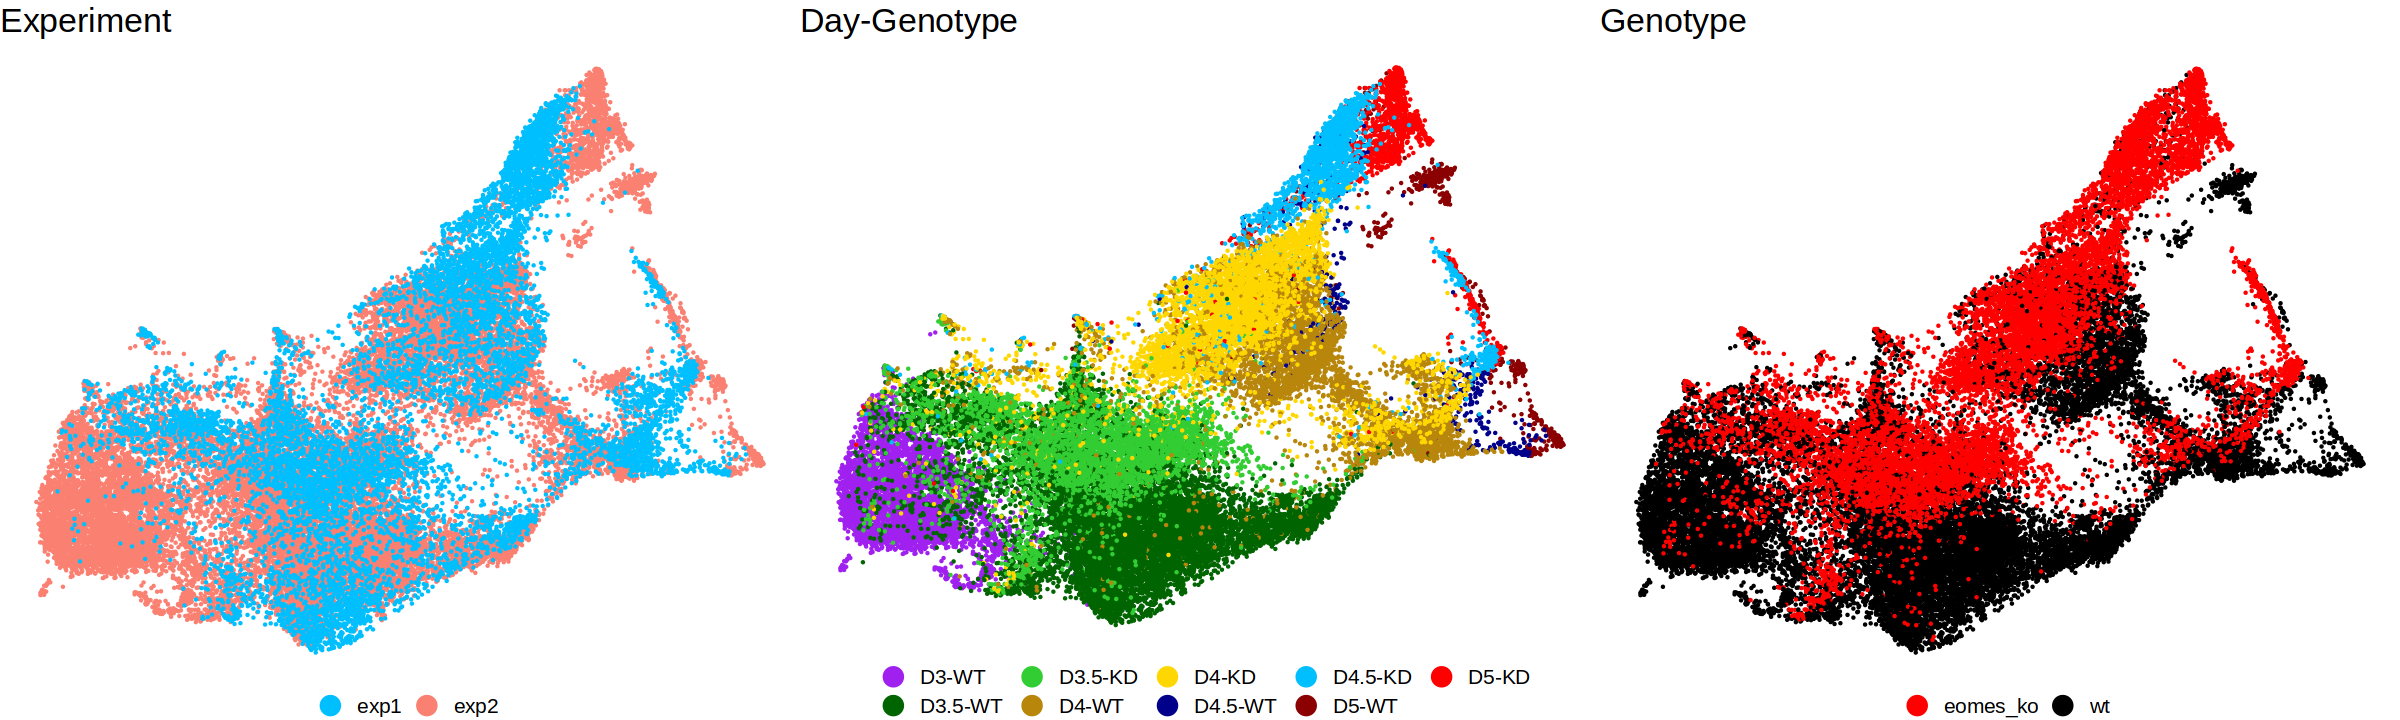

In [60]:
umap.dt = as.data.table(seurat@reductions$umap@cell.embeddings, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    merge(., sample_metadata, by='cell')
plot_umap(umap.dt)

In [61]:
pdf(sprintf('%s/concatenated_umap.pdf', args$outdir), width=15, height=5)
    plot_umap(umap.dt)
dev.off()

png 
  2

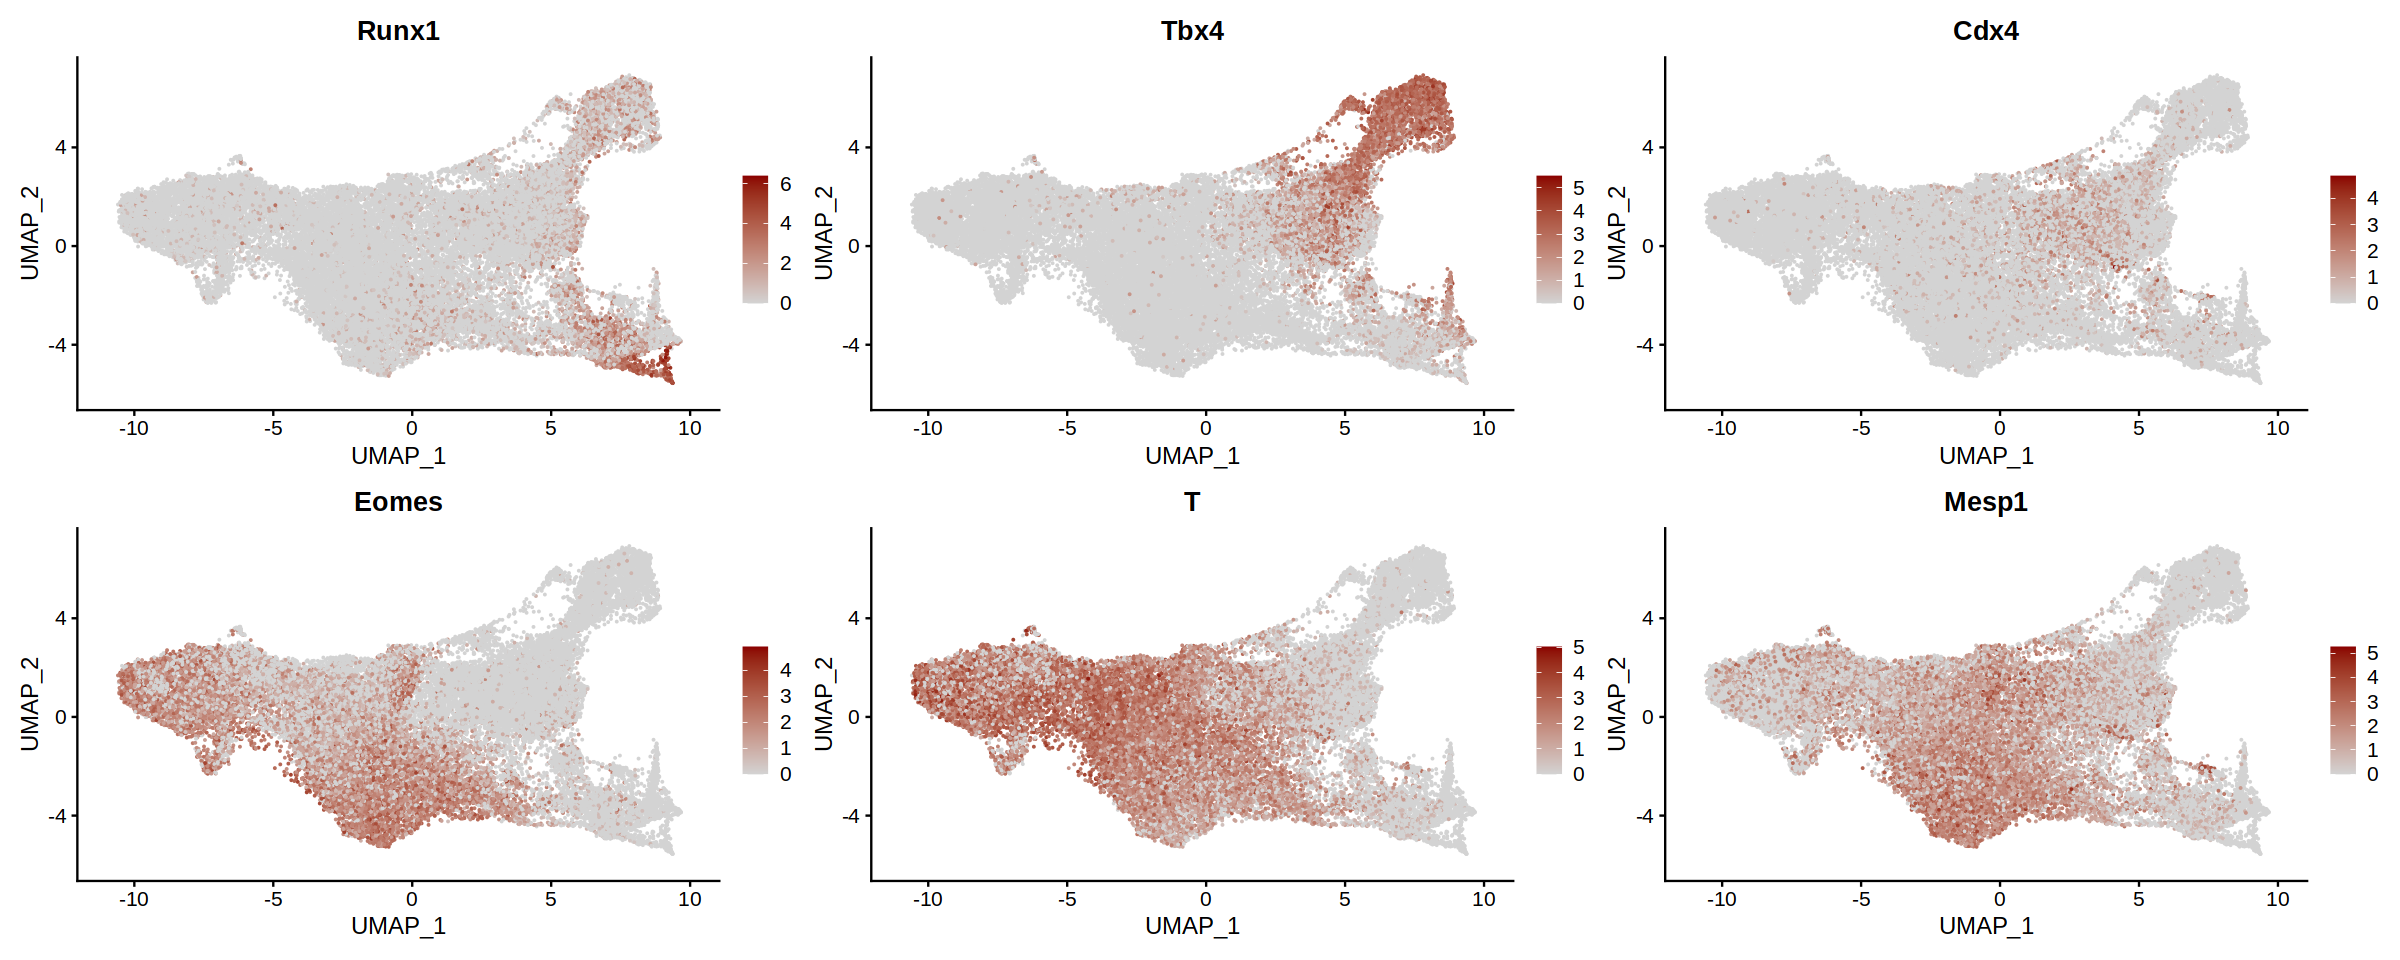

In [129]:
options(repr.plot.width=20, repr.plot.height=8)
FeaturePlot(seurat, features = c("Runx1", 'Tbx4', 'Cdx4', 'Eomes', 'T', 'Mesp1'),
                  reduction = 'umap', max.cutoff = 10, 
                  cols = c("lightgrey","darkred"), ncol = 3)

# MOFA

In [14]:
# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [15]:
library(MOFA2)


Attaching package: ‘MOFA2’


The following object is masked from ‘package:stats’:

    predict




In [23]:
MOFAobject <- create_mofa(list(t(scale(PCA[,1:30])), t(scale(LSI[,1:30]))))

Creating MOFA object from a list of matrices (features as rows, sample as columns)...


View names are not specified in the data, using default: view_1, view_2




Warning message in plot_data_overview(MOFAobject):
“This function is inefficient with large number of cells...”


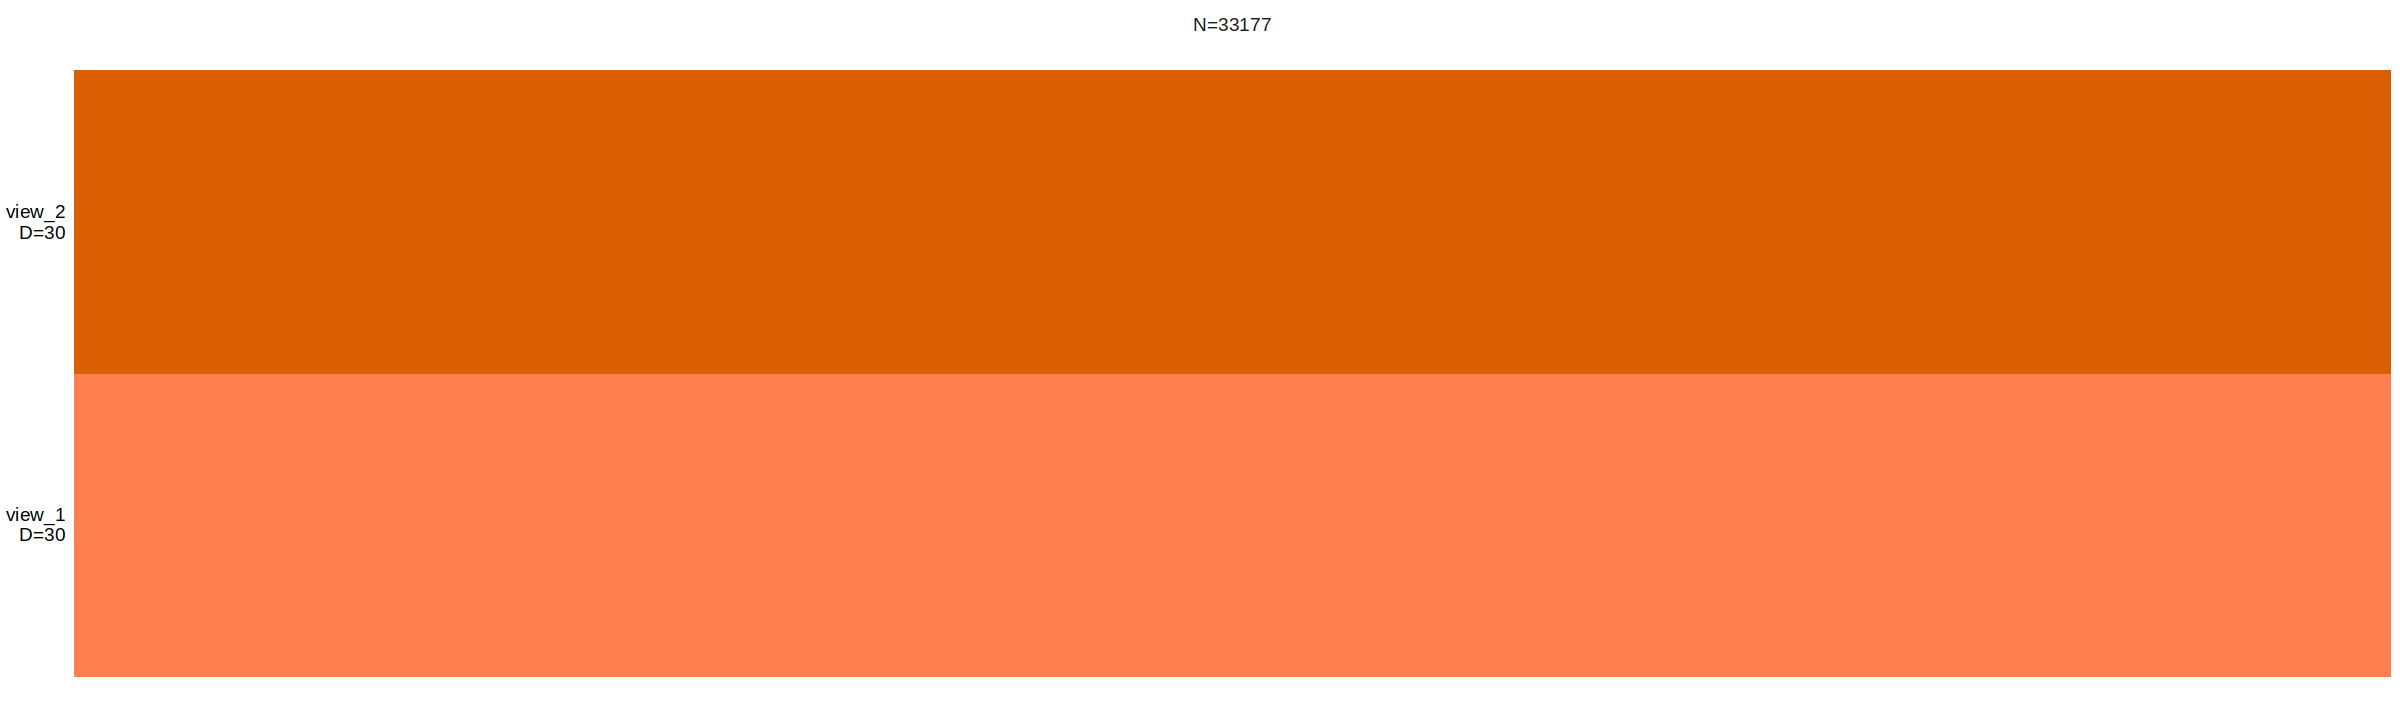

In [24]:
plot_data_overview(MOFAobject)

In [27]:
data_opts <- get_default_data_options(MOFAobject)
head(data_opts)

$scale_views
[1] FALSE

$scale_groups
[1] FALSE

$center_groups
[1] TRUE

$use_float32
[1] TRUE

$views
[1] "view_1" "view_2"

$groups
[1] "group1"

In [28]:
model_opts <- get_default_model_options(MOFAobject)
head(model_opts)

$likelihoods
    view_1     view_2 
"gaussian" "gaussian" 

$num_factors
[1] 25

$spikeslab_factors
[1] FALSE

$spikeslab_weights
[1] FALSE

$ard_factors
[1] FALSE

$ard_weights
[1] TRUE

In [29]:
train_opts <- get_default_training_options(MOFAobject)
head(train_opts)

$maxiter
[1] 1000

$convergence_mode
[1] "fast"

$drop_factor_threshold
[1] -1

$verbose
[1] FALSE

$startELBO
[1] 1

$freqELBO
[1] 5

In [30]:
MOFAobject <- prepare_mofa(
  object = MOFAobject,
  data_options = data_opts,
  model_options = model_opts,
  training_options = train_opts
)

Checking data options...

Checking training options...

Checking model options...



In [32]:
outfile = file.path(args$outdir,"model_v2.hdf5")
MOFAobject.trained <- run_mofa(MOFAobject, outfile)

Connecting to the mofapy2 python package using reticulate (use_basilisk = FALSE)... 
    Please make sure to manually specify the right python binary when loading R with reticulate::use_python(..., force=TRUE) or the right conda environment with reticulate::use_condaenv(..., force=TRUE)
    If you prefer to let us automatically install a conda environment with 'mofapy2' installed using the 'basilisk' package, please use the argument 'use_basilisk = TRUE'


Warning message in .quality_control(object, verbose = verbose):
“Factor(s) 1 are strongly correlated with the total number of expressed features for at least one of your omics. Such factors appear when there are differences in the total 'levels' between your samples, *sometimes* because of poor normalisation in the preprocessing steps.
”


In [16]:
MOFAobject.trained = load_model(file.path(args$outdir,"model_v2.hdf5"))

Warning message in .quality_control(object, verbose = verbose):
“Factor(s) 1 are strongly correlated with the total number of expressed features for at least one of your omics. Such factors appear when there are differences in the total 'levels' between your samples, *sometimes* because of poor normalisation in the preprocessing steps.
”


In [17]:
MOFAobject.trained

Trained MOFA with the following characteristics: 
 Number of views: 2 
 Views names: view_1 view_2 
 Number of features (per view): 30 30 
 Number of groups: 1 
 Groups names: group1 
 Number of samples (per group): 33177 
 Number of factors: 25 


[[1]]

[[2]]


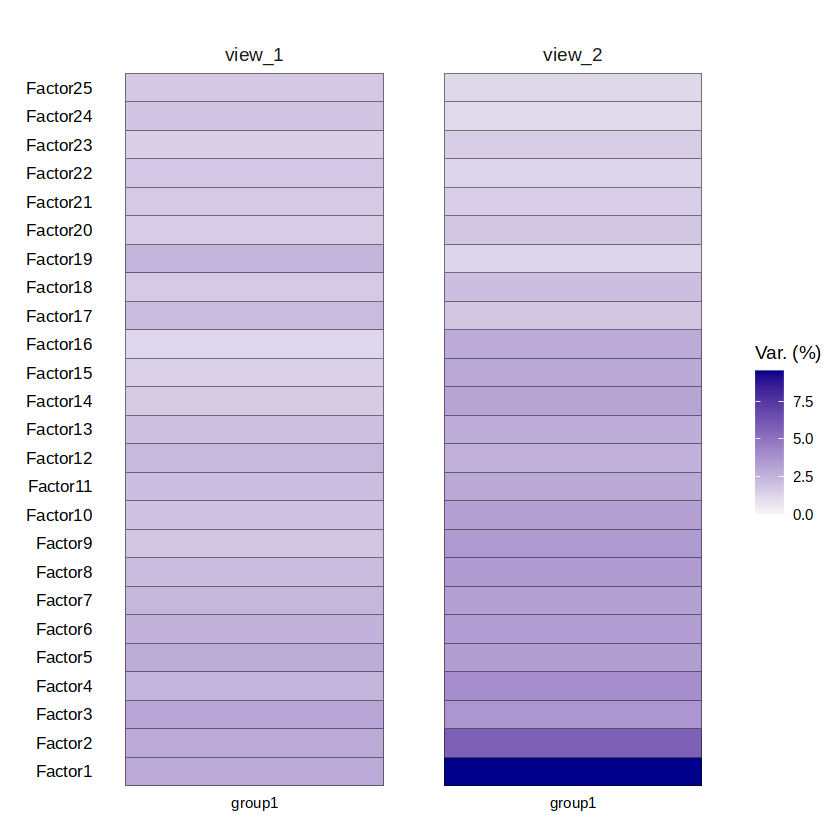

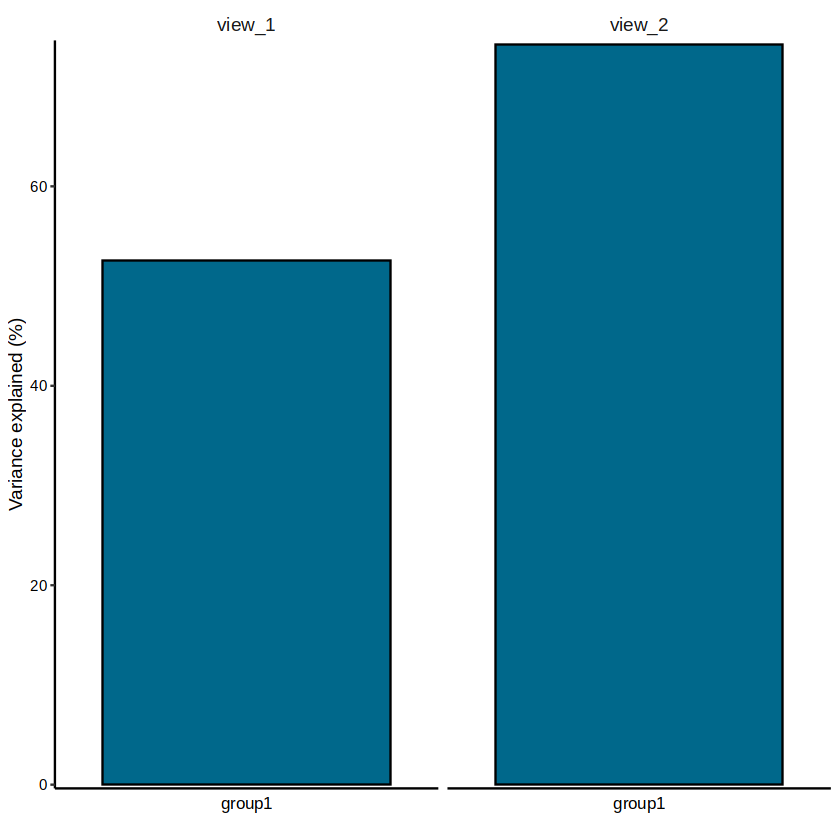

In [18]:
plot_variance_explained(MOFAobject.trained, x="group", y="factor", plot_total = T)

In [19]:
factors <- get_factors(MOFAobject.trained, factors = "all")

In [20]:
head(factors$group1)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,⋯,Factor16,Factor17,Factor18,Factor19,Factor20,Factor21,Factor22,Factor23,Factor24,Factor25
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,-0.3049423,-0.27627128,-0.9977624,-0.6902403,2.018745,-0.57104498,0.3455481,1.6362010,0.6821226,0.75833267,⋯,-0.7438110,0.5549484,-0.6609566,-0.59834462,-0.3000965,-0.260551035,0.90146834,0.62790179,0.4470314,-0.0649573
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,-0.7723742,-0.07324374,-0.3693280,-0.5310805,1.069163,-0.01444246,-0.2260679,0.4107842,-0.7066967,0.41773468,⋯,0.9837219,-0.8193939,0.8789735,1.33624804,-0.7213095,0.278871089,0.37033001,-0.89628971,0.7133136,-0.7402146
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,-0.2642145,-0.31695494,-0.6626379,-0.5478404,2.087515,-0.95893776,0.2893194,0.3768658,0.6275402,0.19606048,⋯,-1.0864297,0.4559564,0.3009181,0.06143595,-0.5499879,-0.360706449,0.31186086,0.24055317,-1.1876936,-0.1576004
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,-0.5919260,-0.11430334,-0.9447572,-0.9004479,1.062239,-0.32098332,-0.5760509,0.6432918,-0.1608550,0.09544766,⋯,0.1255700,0.1053967,0.3133099,0.37594965,-0.1409048,0.826476634,0.05567165,-0.20643380,-1.3517635,-0.6920241
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,-0.8071762,0.13760020,-0.3258813,-0.9599906,1.227144,-0.48682836,-0.7351459,1.4502481,-0.7760847,-0.13085644,⋯,0.8948283,-1.2538360,0.1731105,1.22981334,-0.9101648,-0.733790100,0.03266909,-0.02798048,-0.9047597,0.9036782
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,-0.6391506,0.11311157,-0.6299018,-1.2762926,1.111414,0.48771000,-0.2924405,0.7004918,-0.5418431,0.75646996,⋯,1.5648429,-0.3254874,0.2842935,0.41720590,-0.1626254,-0.004447145,0.32801658,-0.74454772,-0.2267573,-0.3603677


In [21]:
umap = uwot::umap(factors$group1, n_neighbors = 25, min_dist = 0.3)

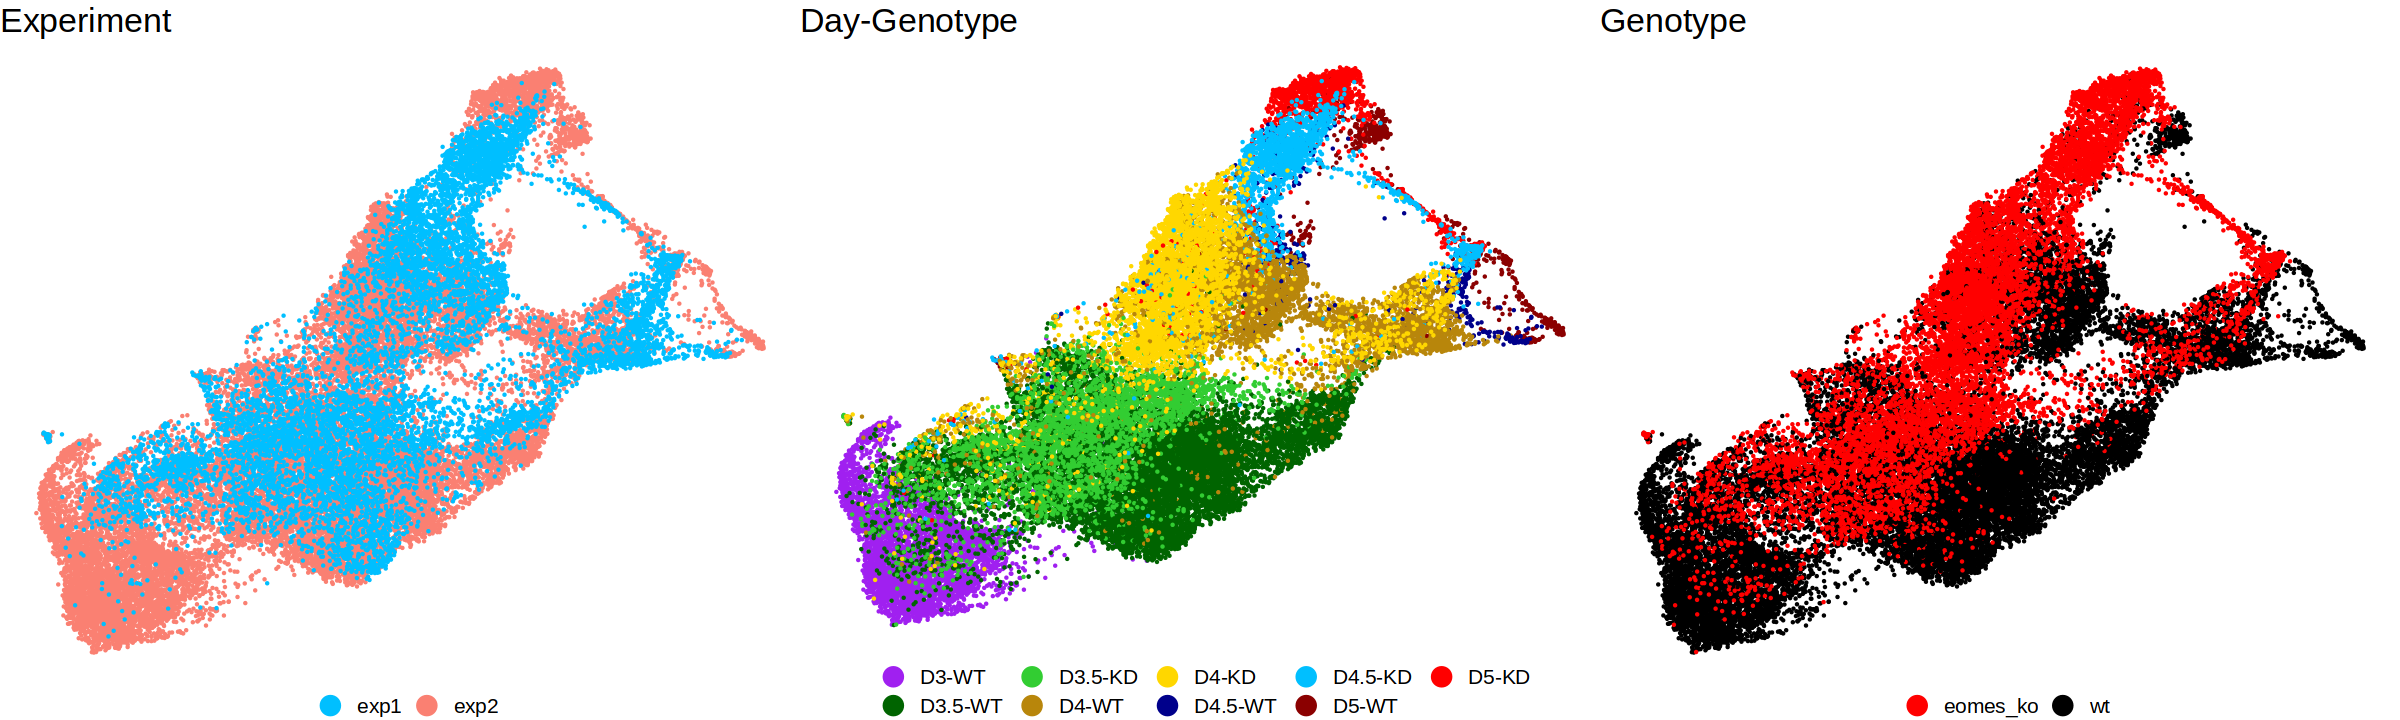

In [26]:
umap.dt = as.data.table(umap, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    .[, UMAP1:=UMAP1*-1] %>% # flip umap2 for consistency
    merge(., sample_metadata, by='cell')
plot_umap(umap.dt)

In [23]:
fwrite(as.data.table(factors$group1, keep.rownames=T) %>% setnames('rn', ' cell'), sprintf('%s/MOFA_factors.txt.gz', args$outdir))

In [27]:
fwrite(umap.dt[,c('cell', 'UMAP1', 'UMAP2')], sprintf('%s/MOFA_umap.txt.gz', args$outdir))

In [28]:
pdf(sprintf('%s/MOFA_umap.pdf', args$outdir), width=15, height=5)
    plot_umap(umap.dt)
dev.off()

png 
  2

#### MOFA LSI/PCA numbers test

In [62]:
MOFAobject <- create_mofa(list(t(scale(PCA[,1:15])), t(scale(LSI[,1:15]))))

Creating MOFA object from a list of matrices (features as rows, sample as columns)...


View names are not specified in the data, using default: view_1, view_2




In [63]:
data_opts <- get_default_data_options(MOFAobject)
model_opts <- get_default_model_options(MOFAobject)
train_opts <- get_default_training_options(MOFAobject)

In [64]:
MOFAobject <- prepare_mofa(
  object = MOFAobject,
  data_options = data_opts,
  model_options = model_opts,
  training_options = train_opts
)

Checking data options...

Checking training options...

Checking model options...



In [65]:
outfile = file.path(args$outdir,"model_v3.hdf5")
MOFAobject.trained <- run_mofa(MOFAobject, outfile)


Connecting to the mofapy2 python package using reticulate (use_basilisk = FALSE)... 
    Please make sure to manually specify the right python binary when loading R with reticulate::use_python(..., force=TRUE) or the right conda environment with reticulate::use_condaenv(..., force=TRUE)
    If you prefer to let us automatically install a conda environment with 'mofapy2' installed using the 'basilisk' package, please use the argument 'use_basilisk = TRUE'


8 factors were found to explain no variance and they were removed for downstream analysis. You can disable this option by setting load_model(..., remove_inactive_factors = FALSE)



In [66]:
factors <- get_factors(MOFAobject.trained, factors = "all")

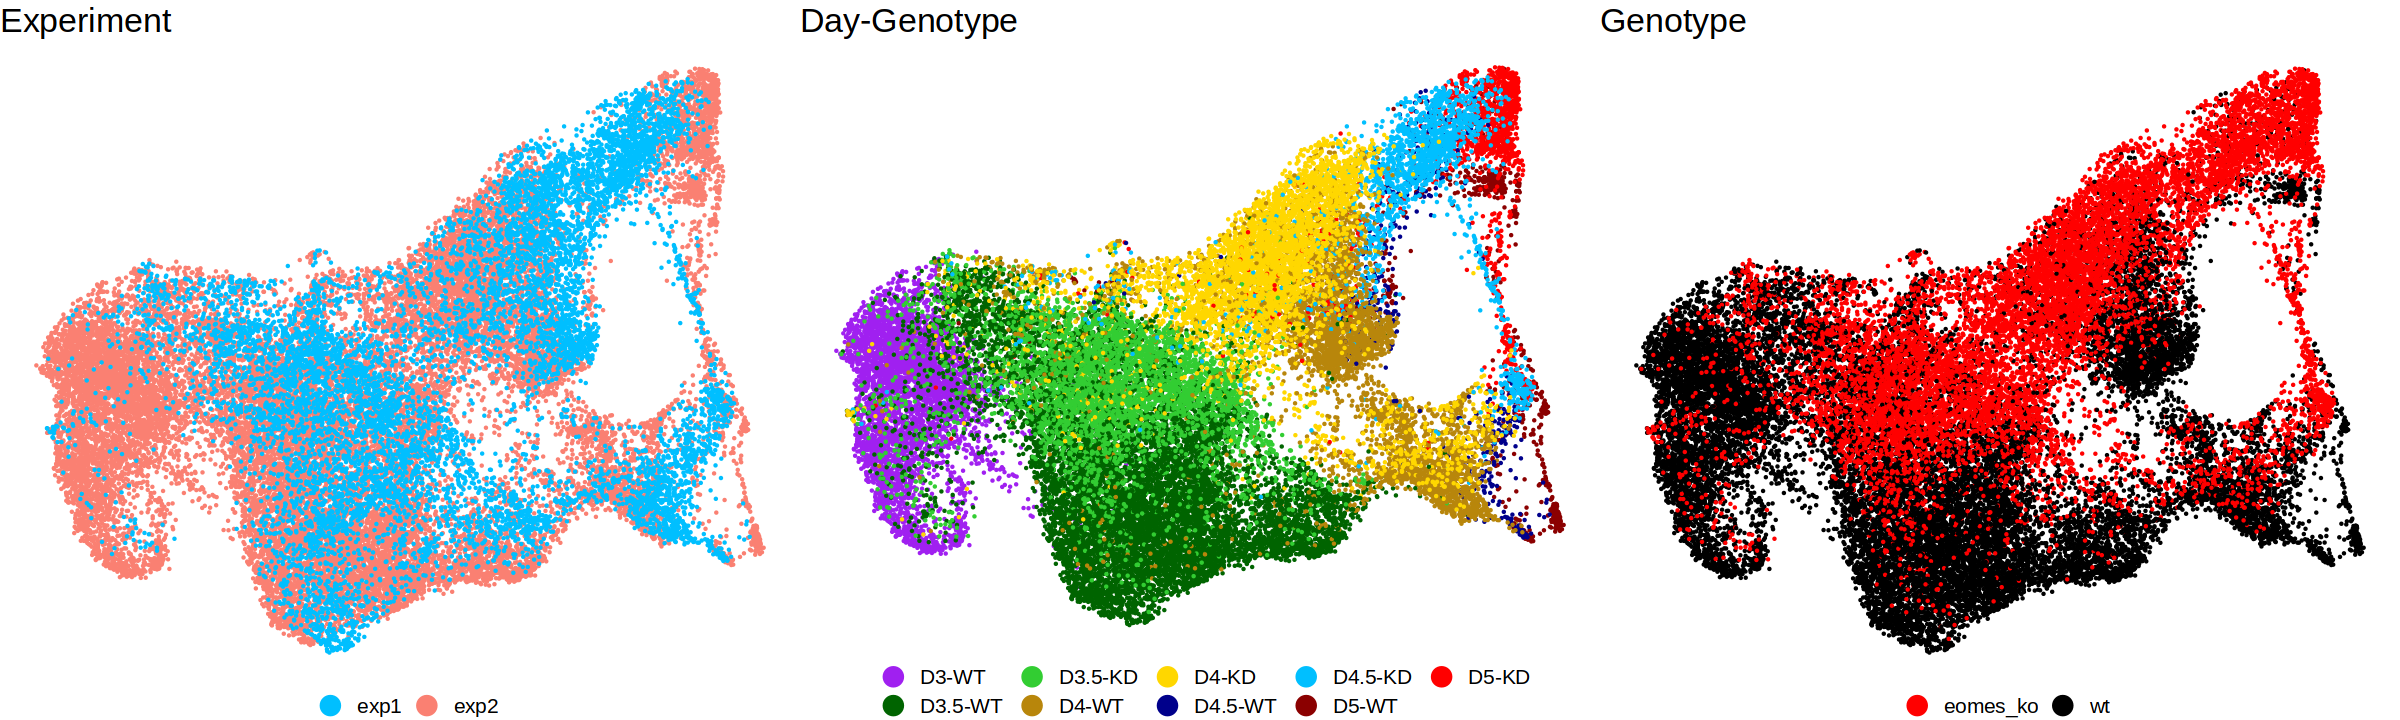

In [67]:
umap = uwot::umap(factors$group1, n_neighbors = 25, min_dist = 0.3)
umap.dt = as.data.table(umap, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    .[, UMAP2:=UMAP2*-1] %>% # flip umap2 for consistency
    merge(., sample_metadata, by='cell')
plot_umap(umap.dt)